**Tiền xử lý dữ liệu**

In [ ]:
import pandas as pd
import re
import unicodedata


def clean_text(text: str) -> str:
    """Chuẩn hóa và làm sạch 1 đoạn văn bản tiếng Việt."""
    if pd.isna(text):
        return text
    text = str(text)
    text = unicodedata.normalize('NFC', text)
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'&\w+;', ' ', text)

    emoji_pattern = re.compile(
        "["
        "\U0001F300-\U0001FAFF"   # biểu tượng, mặt cười...
        "\U00002600-\U000027BF"   # ký hiệu khác
        "\U0001F1E6-\U0001F1FF"   # cờ quốc gia
        "]+", flags=re.UNICODE)
    text = emoji_pattern.sub(' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text


def preprocess_dataset(df: pd.DataFrame, text_col: str = "text", min_len: int = 5) -> pd.DataFrame:
    """Áp dụng toàn bộ pipeline làm sạch + loại nhiễu cho cả bảng dữ liệu."""
    df = df.copy()
    print(f"Trước xử lý: {df.shape}")
    df[text_col] = df[text_col].apply(clean_text)
    before = len(df)
    df = df[df[text_col].str.len() > 0]
    print(f"Loại {before - len(df)} dòng rỗng sau khi làm sạch")
    before = len(df)
    df = df.drop_duplicates(subset=[text_col]).reset_index(drop=True)
    print(f"Loại {before - len(df)} dòng trùng lặp sau chuẩn hóa")
    before = len(df)
    df = df[df[text_col].str.len() >= min_len].copy()
    print(f"Loại {before - len(df)} dòng quá ngắn (<{min_len} ký tự)")

    print(f"Sau xử lý: {df.shape}")
    return df

if __name__ == "__main__":
    INPUT_FILE = "merged_shuffled_dataset.csv"
    df_raw = pd.read_csv(INPUT_FILE, lineterminator='\n')
    if "post_message" in df_raw.columns and "text" not in df_raw.columns:
        df_raw = df_raw.rename(columns={"post_message": "text"})

    meta_cols = ["user_name", "timestamp_post", "num_like_post", "num_comment_post", "num_share_post"]
    df_raw = df_raw.drop(columns=[c for c in meta_cols if c in df_raw.columns])

    df_clean = preprocess_dataset(df_raw, text_col="text", min_len=5)
    df_clean.to_csv("cleaned_dataset.csv", index=False)
    print("Đã lưu cleaned_dataset.csv")
    print("Các cột còn lại:", df_clean.columns.tolist())

Trước xử lý: (13741, 3)
Loại 18 dòng rỗng sau khi làm sạch
Loại 43 dòng trùng lặp sau chuẩn hóa
Loại 1 dòng quá ngắn (<5 ký tự)
Sau xử lý: (13679, 3)
Đã lưu cleaned_dataset.csv
Các cột còn lại: ['text', 'label', 'source']


**Phân tích dữ liệu (EDA)**

Đã lưu biểu đồ EDA: eda_overview.png


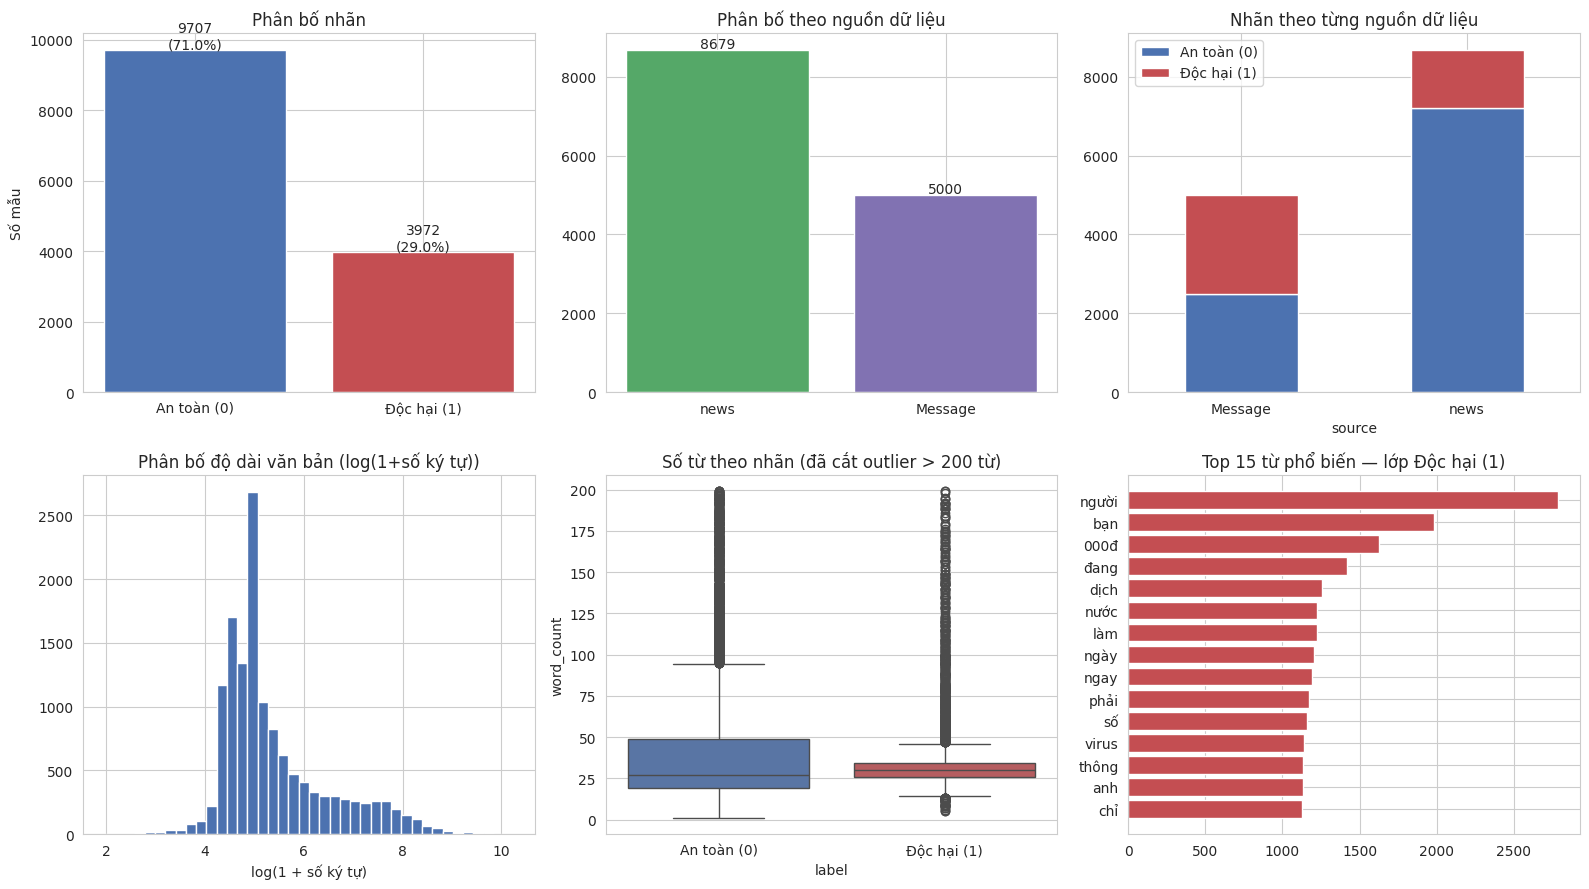


=== THỐNG KÊ MÔ TẢ ===
Tổng số mẫu: 13679
  Nhãn 0: 9707 (70.96%)
  Nhãn 1: 3972 (29.04%)
Độ dài (ký tự): min=6, max=28681, mean=518.1, median=150
Số từ: min=1, max=6413, mean=104.5, median=31

Top 15 từ — lớp AN TOÀN (0): [('người', 10053), ('bệnh', 7066), ('ngày', 6886), ('công', 4765), ('covid', 4628), ('dịch', 4560), ('trên', 4168), ('nhân', 3824), ('theo', 3378), ('nước', 3259), ('số', 3214), ('nhà', 3194), ('đi', 3145), ('nhiều', 3140), ('đang', 3082)]

Top 15 từ — lớp ĐỘC HẠI (1): [('người', 2790), ('bạn', 1984), ('000đ', 1624), ('đang', 1421), ('dịch', 1259), ('nước', 1226), ('làm', 1223), ('ngày', 1204), ('ngay', 1189), ('phải', 1170), ('số', 1156), ('virus', 1139), ('thông', 1135), ('anh', 1130), ('chỉ', 1129)]


In [ ]:

import pandas as pd
import numpy as np
import re
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

STOPWORDS_VN = set("""và là của có cho được các một những trong đã sẽ với không
này để khi bị ra vào ở đó thì nên như mà nhưng còn tại về sau trước cũng đến
từ nếu nào ai gì""".split())


def top_words(texts, n=15, stopwords=STOPWORDS_VN):
    """Đếm tần suất từ phổ biến nhất (tách từ đơn giản theo khoảng trắng/regex,
    KHÔNG thay thế cho tách từ VnCoreNLP — chỉ dùng để khảo sát nhanh)."""
    words = []
    for t in texts:
        for w in re.findall(r'\w+', str(t).lower()):
            if len(w) > 1 and w not in stopwords and not w.isdigit():
                words.append(w)
    return Counter(words).most_common(n)


def run_eda(df: pd.DataFrame, save_path: str = "eda_overview.png"):
    df = df.copy()
    df['length'] = df['text'].str.len()
    df['word_count'] = df['text'].str.split().apply(len)

    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    colors = ['#4C72B0', '#C44E52']
    labels = ['An toàn (0)', 'Độc hại (1)']
    label_counts = df['label'].value_counts().sort_index()
    axes[0, 0].bar(labels, label_counts.values, color=colors)
    for i, v in enumerate(label_counts.values):
        axes[0, 0].text(i, v + 50, f"{v}\n({v/len(df)*100:.1f}%)", ha='center', fontsize=10)
    axes[0, 0].set_title("Phân bố nhãn")
    axes[0, 0].set_ylabel("Số mẫu")
    if 'source' in df.columns:
        src_counts = df['source'].value_counts()
        axes[0, 1].bar(src_counts.index, src_counts.values, color=['#55A868', '#8172B2'])
        for i, v in enumerate(src_counts.values):
            axes[0, 1].text(i, v + 50, str(v), ha='center', fontsize=10)
        axes[0, 1].set_title("Phân bố theo nguồn dữ liệu")

        ct = pd.crosstab(df['source'], df['label'])
        ct.plot(kind='bar', stacked=True, ax=axes[0, 2], color=colors, legend=True)
        axes[0, 2].set_title("Nhãn theo từng nguồn dữ liệu")
        axes[0, 2].legend(labels)
        axes[0, 2].tick_params(axis='x', rotation=0)
    else:
        axes[0, 1].axis('off')
        axes[0, 2].axis('off')
    axes[1, 0].hist(np.log1p(df['length']), bins=40, color='#4C72B0', edgecolor='white')
    axes[1, 0].set_title("Phân bố độ dài văn bản (log(1+số ký tự))")
    axes[1, 0].set_xlabel("log(1 + số ký tự)")
    plot_df = df[df['word_count'] < 200]
    sns.boxplot(x='label', y='word_count', data=plot_df, ax=axes[1, 1], hue='label',
                palette=colors, legend=False)
    axes[1, 1].set_xticks([0, 1]); axes[1, 1].set_xticklabels(labels)
    axes[1, 1].set_title("Số từ theo nhãn (đã cắt outlier > 200 từ)")
    tw1 = top_words(df[df['label'] == 1]['text'])
    words, counts = zip(*tw1)
    axes[1, 2].barh(words[::-1], counts[::-1], color='#C44E52')
    axes[1, 2].set_title("Top 15 từ phổ biến — lớp Độc hại (1)")

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"Đã lưu biểu đồ EDA: {save_path}")
    plt.show()

    print("\n=== THỐNG KÊ MÔ TẢ ===")
    print(f"Tổng số mẫu: {len(df)}")
    for lbl, cnt in label_counts.items():
        print(f"  Nhãn {lbl}: {cnt} ({cnt/len(df)*100:.2f}%)")
    print(f"Độ dài (ký tự): min={df['length'].min()}, max={df['length'].max()}, "
          f"mean={df['length'].mean():.1f}, median={df['length'].median():.0f}")
    print(f"Số từ: min={df['word_count'].min()}, max={df['word_count'].max()}, "
          f"mean={df['word_count'].mean():.1f}, median={df['word_count'].median():.0f}")
    print("\nTop 15 từ — lớp AN TOÀN (0):", top_words(df[df['label'] == 0]['text']))
    print("\nTop 15 từ — lớp ĐỘC HẠI (1):", tw1)


if __name__ == "__main__":
    df_clean = pd.read_csv("cleaned_dataset.csv")
    run_eda(df_clean, save_path="eda_overview.png")

Chia dữ liệu Train / Validation / Test

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("cleaned_dataset.csv")

# Chia 80% train, 10% val, 10% test — có phân tầng (stratify) theo nhãn
# để tỉ lệ lớp 0/1 đồng nhất giữa 3 tập
train_df, temp_df = train_test_split(
    df, test_size=0.2, stratify=df["label"], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df["label"], random_state=42
)

print("Train:", train_df.shape, train_df["label"].value_counts().to_dict())
print("Val  :", val_df.shape, val_df["label"].value_counts().to_dict())
print("Test :", test_df.shape, test_df["label"].value_counts().to_dict())

train_df.to_csv("train_split.csv", index=False)
val_df.to_csv("val_split.csv", index=False)
test_df.to_csv("test_split.csv", index=False)
print("\nĐã lưu train_split.csv, val_split.csv, test_split.csv")


Train: (10943, 3) {0: 7765, 1: 3178}
Val  : (1368, 3) {0: 971, 1: 397}
Test : (1368, 3) {0: 971, 1: 397}

Đã lưu train_split.csv, val_split.csv, test_split.csv


**FEATURE ENGINEERING**

In [ ]:

import pandas as pd
import pickle
from sklearn.feature_extraction.text import TfidfVectorizer

train_df = pd.read_csv("train_split.csv")
val_df   = pd.read_csv("val_split.csv")
test_df  = pd.read_csv("test_split.csv")

tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=20000,
    min_df=2,
    sublinear_tf=True,
)

X_train_tfidf = tfidf.fit_transform(train_df["text"])   # chỉ fit trên tập train
X_val_tfidf   = tfidf.transform(val_df["text"])
X_test_tfidf  = tfidf.transform(test_df["text"])

print("Kích thước ma trận TF-IDF:")
print("  Train:", X_train_tfidf.shape)
print("  Val  :", X_val_tfidf.shape)
print("  Test :", X_test_tfidf.shape)

# Lưu vectorizer để dùng lại lúc suy luận
with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

import scipy.sparse as sp
sp.save_npz("X_train_tfidf.npz", X_train_tfidf)
sp.save_npz("X_val_tfidf.npz", X_val_tfidf)
sp.save_npz("X_test_tfidf.npz", X_test_tfidf)

print("\nĐã lưu: tfidf_vectorizer.pkl, X_train_tfidf.npz, X_val_tfidf.npz, X_test_tfidf.npz")

# Xem thử 20 đặc trưng (từ/cụm từ) có trọng số IDF thấp nhất (xuất hiện nhiều nhất)
import numpy as np
feature_names = np.array(tfidf.get_feature_names_out())
idf_scores = tfidf.idf_
top_common_idx = np.argsort(idf_scores)[:20]
print("\n20 đặc trưng phổ biến nhất (IDF thấp nhất):")
print(feature_names[top_common_idx].tolist())

Kích thước ma trận TF-IDF:
  Train: (10943, 20000)
  Val  : (1368, 20000)
  Test : (1368, 20000)

Đã lưu: tfidf_vectorizer.pkl, X_train_tfidf.npz, X_val_tfidf.npz, X_test_tfidf.npz

20 đặc trưng phổ biến nhất (IDF thấp nhất):
['của', 'để', 'đã', 'có', 'và', 'không', 'được', 'trong', 'là', 'cho', 'tại', 'người', 'các', 'này', 'với', 'bị', 'đến', 'công', 'ngày', 'về']


**Huấn luyện mô hình phoBERT**

In [ ]:
!pip install -q transformers datasets scikit-learn torch accelerate py_vncorenlp

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 30.7 MB/s eta 0:00:00


Train: (10943, 3) | Val: (1368, 3) | Test: (1368, 3)


config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/895k [00:00<?, ?B/s]

bpe.codes:   0%|          | 0.00/1.14M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.13M [00:00<?, ?B/s]

...

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.128021,0.131524,0.954678,0.951482,0.889169,0.919271
2,0.075894,0.102083,0.975877,0.984043,0.931990,0.957309
3,0.031294,0.120362,0.975146,0.981432,0.931990,0.956072
4,0.028587,0.124096,0.973684,0.983914,0.924433,0.953247


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

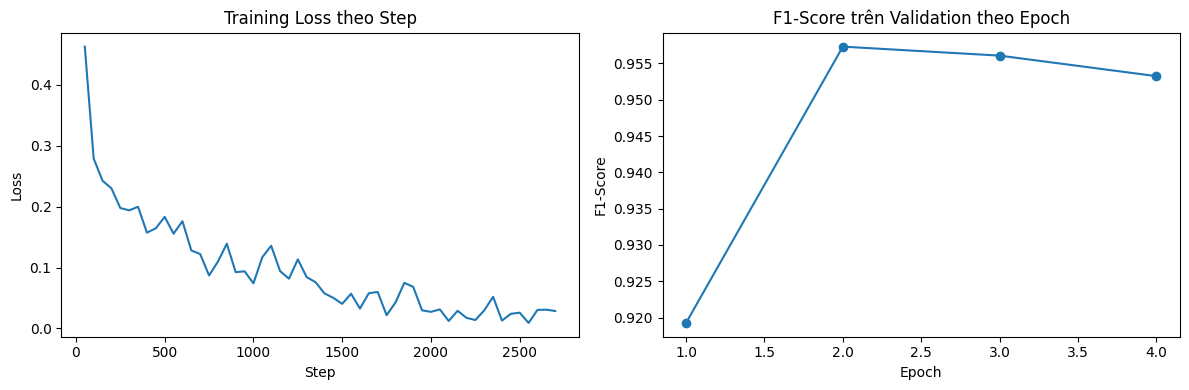


========== PHOBERT — KẾT QUẢ TRÊN TẬP TEST ==========
Accuracy : 97.00%
Precision: 97.85%
Recall   : 91.69%
F1-Score : 94.67%
              precision    recall  f1-score   support

 An toàn (0)       0.97      0.99      0.98       971
 Độc hại (1)       0.98      0.92      0.95       397

    accuracy                           0.97      1368
   macro avg       0.97      0.95      0.96      1368
weighted avg       0.97      0.97      0.97      1368


Ma trận nhầm lẫn (Confusion Matrix):
[[963   8]
 [ 33 364]]


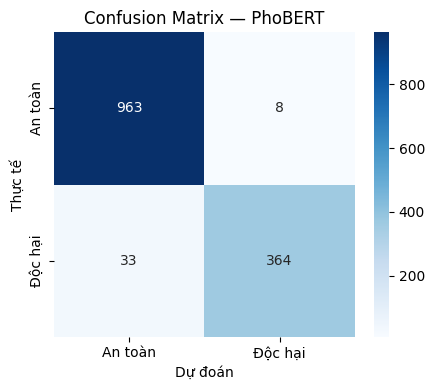

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Hoàn tất. Đã lưu: phobert_training_curves.png, cm_phobert.png, phobert_results.csv


In [ ]:
import os
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback
)
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
# 1) Load dữ liệu — upload train_split.csv, val_split.csv, test_split.csv lên Colab trước
train_df = pd.read_csv("train_split.csv")
val_df   = pd.read_csv("val_split.csv")
test_df  = pd.read_csv("test_split.csv")
print("Train:", train_df.shape, "| Val:", val_df.shape, "| Test:", test_df.shape)

# 2) Tách từ tiếng Việt bằng VnCoreNLP — BẮT BUỘC đối với PhoBERT
import py_vncorenlp
os.makedirs('/content/vncorenlp', exist_ok=True)
py_vncorenlp.download_model(save_dir='/content/vncorenlp')

rdrsegmenter = py_vncorenlp.VnCoreNLP(save_dir='/content/vncorenlp')

def segment(text):
    try:
        return " ".join(rdrsegmenter.word_segment(str(text)))
    except Exception:
        return str(text)

train_df['text'] = train_df['text'].apply(segment)
val_df['text']   = val_df['text'].apply(segment)
test_df['text']  = test_df['text'].apply(segment)
# 3) Load PhoBERT tokenizer & model
MODEL_NAME = "vinai/phobert-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
# 4) Dataset class
MAX_LEN = 256

class NewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=MAX_LEN):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["labels"] = torch.tensor(int(self.labels[idx]), dtype=torch.long)
        return item

train_ds = NewsDataset(train_df["text"], train_df["label"], tokenizer)
val_ds   = NewsDataset(val_df["text"], val_df["label"], tokenizer)
test_ds  = NewsDataset(test_df["text"], test_df["label"], tokenizer)
# 5) Hàm tính chỉ số đánh giá
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary", zero_division=0
    )
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}
# 6) Cấu hình huấn luyện
training_args = TrainingArguments(
    output_dir="./phobert_fakenews",
    num_train_epochs=4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_dir="./logs",
    logging_steps=50,
    report_to="none",
    fp16=torch.cuda.is_available(),
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)
# 7) Huấn luyện
trainer.train()
history = trainer.state.log_history
train_loss = [(h["step"], h["loss"]) for h in history if "loss" in h]
eval_f1 = [(h["epoch"], h["eval_f1"]) for h in history if "eval_f1" in h]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
if train_loss:
    steps, losses = zip(*train_loss)
    axes[0].plot(steps, losses)
    axes[0].set_title("Training Loss theo Step")
    axes[0].set_xlabel("Step"); axes[0].set_ylabel("Loss")
if eval_f1:
    epochs, f1s = zip(*eval_f1)
    axes[1].plot(epochs, f1s, marker="o")
    axes[1].set_title("F1-Score trên Validation theo Epoch")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("F1-Score")
plt.tight_layout()
plt.savefig("phobert_training_curves.png", dpi=150)
plt.show()
# 8) Đánh giá trên tập TEST
test_pred = trainer.predict(test_ds)
y_true = test_pred.label_ids
y_pred = np.argmax(test_pred.predictions, axis=1)

acc = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary")

print("\n========== PHOBERT — KẾT QUẢ TRÊN TẬP TEST ==========")
print(f"Accuracy : {acc*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall   : {recall*100:.2f}%")
print(f"F1-Score : {f1*100:.2f}%")
print(classification_report(y_true, y_pred, target_names=["An toàn (0)", "Độc hại (1)"]))

cm = confusion_matrix(y_true, y_pred)
print("\nMa trận nhầm lẫn (Confusion Matrix):")
print(cm)

plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["An toàn", "Độc hại"], yticklabels=["An toàn", "Độc hại"])
plt.xlabel("Dự đoán"); plt.ylabel("Thực tế")
plt.title("Confusion Matrix — PhoBERT")
plt.tight_layout()
plt.savefig("cm_phobert.png", dpi=150)
plt.show()

pd.DataFrame([{"model": "PhoBERT", "accuracy": acc*100, "precision": precision*100,
               "recall": recall*100, "f1": f1*100}]).to_csv("phobert_results.csv", index=False)

trainer.save_model("./phobert_fakenews_final")
tokenizer.save_pretrained("./phobert_fakenews_final")

print("\n✅ Hoàn tất. Đã lưu: phobert_training_curves.png, cm_phobert.png, phobert_results.csv")

**Huấn luyện mô hình LSTM**

Đang chạy trên: cuda
Train: (10943, 3) | Val: (1368, 3) | Test: (1368, 3)
Kích thước từ điển: 20002
LSTMClassifier(
  (embedding): Embedding(20002, 128, padding_idx=0)
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=2, bias=True)
)
Epoch 1/10 - loss: 0.3065 - val_f1: 81.68%
Epoch 2/10 - loss: 0.1935 - val_f1: 84.41%
Epoch 3/10 - loss: 0.1178 - val_f1: 86.00%
Epoch 4/10 - loss: 0.0636 - val_f1: 87.28%
Epoch 5/10 - loss: 0.0424 - val_f1: 87.67%
Epoch 6/10 - loss: 0.0147 - val_f1: 88.54%
Epoch 7/10 - loss: 0.0157 - val_f1: 86.91%
Epoch 8/10 - loss: 0.0183 - val_f1: 88.08%
Epoch 9/10 - loss: 0.0116 - val_f1: 88.86%
Epoch 10/10 - loss: 0.0073 - val_f1: 87.87%


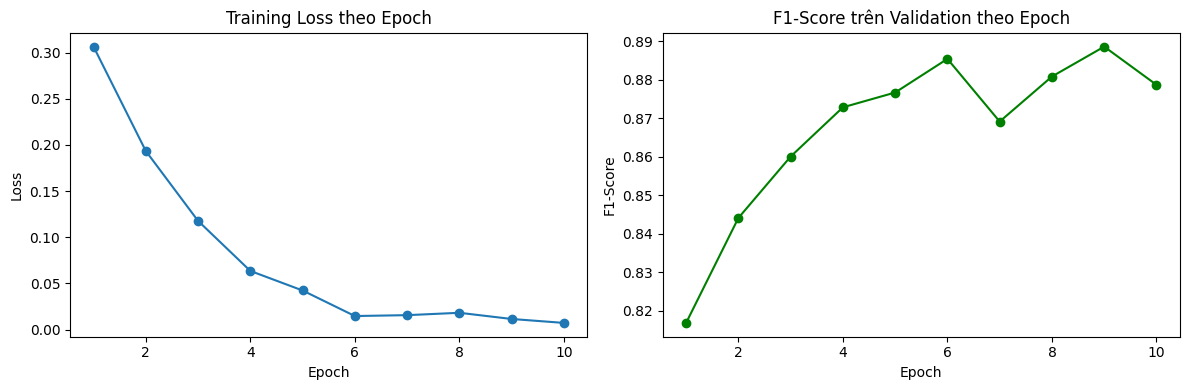


========== LSTM — KẾT QUẢ TRÊN TẬP TEST ==========
Accuracy : 93.64%
Precision: 92.12%
Recall   : 85.39%
F1-Score : 88.63%
              precision    recall  f1-score   support

 An toàn (0)       0.94      0.97      0.96       971
 Độc hại (1)       0.92      0.85      0.89       397

    accuracy                           0.94      1368
   macro avg       0.93      0.91      0.92      1368
weighted avg       0.94      0.94      0.94      1368



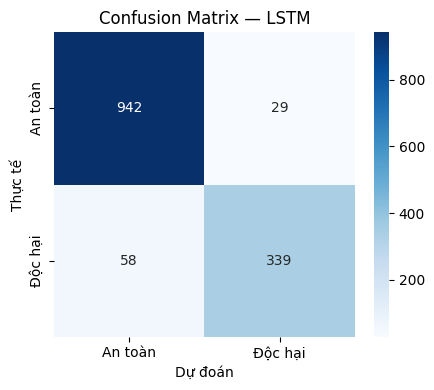

In [ ]:

!pip install -q torch scikit-learn

import re
import pickle
from collections import Counter

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Đang chạy trên:", device)

train_df = pd.read_csv("train_split.csv")
val_df   = pd.read_csv("val_split.csv")
test_df  = pd.read_csv("test_split.csv")
print("Train:", train_df.shape, "| Val:", val_df.shape, "| Test:", test_df.shape)

def simple_tokenize(text):
    return re.findall(r"\w+", str(text).lower())


MAX_VOCAB = 20000
counter = Counter()
for text in train_df["text"]:
    counter.update(simple_tokenize(text))

vocab = {"<PAD>": 0, "<UNK>": 1}
for word, _ in counter.most_common(MAX_VOCAB):
    vocab[word] = len(vocab)

print(f"Kích thước từ điển: {len(vocab)}")
with open("lstm_vocab.pkl", "wb") as f:
    pickle.dump(vocab, f)

def encode(text, max_len=256):
    tokens = simple_tokenize(text)
    ids = [vocab.get(t, vocab["<UNK>"]) for t in tokens][:max_len]
    ids = ids + [vocab["<PAD>"]] * (max_len - len(ids))
    return ids

MAX_LEN = 256
class TextDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = list(texts)
        self.labels = list(labels)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        ids = encode(self.texts[idx], MAX_LEN)
        return (torch.tensor(ids, dtype=torch.long),
                torch.tensor(int(self.labels[idx]), dtype=torch.long))

train_ds = TextDataset(train_df["text"], train_df["label"])
val_ds   = TextDataset(val_df["text"], val_df["label"])
test_ds  = TextDataset(test_df["text"], test_df["label"])

BATCH_SIZE = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=64, shuffle=False)

class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_size=128, num_layers=2,
                 dropout=0.3, num_classes=2, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(
            embed_dim, hidden_size, num_layers=num_layers,
            batch_first=True, bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        emb = self.embedding(x)
        _, (h_n, _) = self.lstm(emb)
        h_forward = h_n[-2]
        h_backward = h_n[-1]
        h = torch.cat([h_forward, h_backward], dim=1)
        return self.fc(h)

model = LSTMClassifier(vocab_size=len(vocab)).to(device)
print(model)


EPOCHS = 10
LR = 1e-3

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss()

history = {"train_loss": [], "val_f1": []}

def evaluate_loader(loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    return np.array(all_labels), np.array(all_preds)

best_f1 = -1
for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()
        epoch_loss += loss.item() * x.size(0)

    epoch_loss /= len(train_ds)
    y_true_val, y_pred_val = evaluate_loader(val_loader)
    _, _, val_f1, _ = precision_recall_fscore_support(
        y_true_val, y_pred_val, average="binary", zero_division=0
    )
    history["train_loss"].append(epoch_loss)
    history["val_f1"].append(val_f1)
    print(f"Epoch {epoch}/{EPOCHS} - loss: {epoch_loss:.4f} - val_f1: {val_f1*100:.2f}%")

    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), "lstm_best.pt")


model.load_state_dict(torch.load("lstm_best.pt"))


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, EPOCHS + 1), history["train_loss"], marker="o")
axes[0].set_title("Training Loss theo Epoch")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[1].plot(range(1, EPOCHS + 1), history["val_f1"], marker="o", color="green")
axes[1].set_title("F1-Score trên Validation theo Epoch")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("F1-Score")
plt.tight_layout()
plt.savefig("lstm_training_curves.png", dpi=150)
plt.show()


y_true, y_pred = evaluate_loader(test_loader)

acc = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary")

print("\n========== LSTM — KẾT QUẢ TRÊN TẬP TEST ==========")
print(f"Accuracy : {acc*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall   : {recall*100:.2f}%")
print(f"F1-Score : {f1*100:.2f}%")
print(classification_report(y_true, y_pred, target_names=["An toàn (0)", "Độc hại (1)"]))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["An toàn", "Độc hại"], yticklabels=["An toàn", "Độc hại"])
plt.xlabel("Dự đoán"); plt.ylabel("Thực tế")
plt.title("Confusion Matrix — LSTM")
plt.tight_layout()
plt.savefig("cm_lstm.png", dpi=150)
plt.show()

pd.DataFrame([{
    "model": "LSTM", "accuracy": acc*100, "precision": precision*100,
    "recall": recall*100, "f1": f1*100
}]).to_csv("lstm_results.csv", index=False)


**Huấn luyện mô hình Naive Bayes và SVM**

In [ ]:

import pandas as pd
import numpy as np
import scipy.sparse as sp
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report
)
X_train = sp.load_npz("X_train_tfidf.npz")
X_val   = sp.load_npz("X_val_tfidf.npz")
X_test  = sp.load_npz("X_test_tfidf.npz")

y_train = pd.read_csv("train_split.csv")["label"].values
y_val   = pd.read_csv("val_split.csv")["label"].values
y_test  = pd.read_csv("test_split.csv")["label"].values


def evaluate(model_name, y_true, y_pred, cm_save_path):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", zero_division=0
    )
    print(f"\n========== {model_name} — KẾT QUẢ TRÊN TẬP TEST ==========")
    print(f"Accuracy : {acc*100:.2f}%")
    print(f"Precision: {precision*100:.2f}%")
    print(f"Recall   : {recall*100:.2f}%")
    print(f"F1-Score : {f1*100:.2f}%")

    print("\nBáo cáo phân loại (Classification Report):")
    print(classification_report(y_true, y_pred, target_names=["An toàn (0)", "Độc hại (1)"]))

    # TÍNH TOÁN MA TRẬN NHẦM LẪN
    cm = confusion_matrix(y_true, y_pred)

    # THÊM DÒNG NÀY ĐỂ IN MA TRẬN RA MÀN HÌNH
    print("Ma trận nhầm lẫn (Confusion Matrix):")
    print(cm)

    # Đoạn này giữ nguyên: Vẽ biểu đồ và lưu thành file ảnh .png
    plt.figure(figsize=(4.5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["An toàn", "Độc hại"], yticklabels=["An toàn", "Độc hại"])
    plt.xlabel("Dự đoán")
    plt.ylabel("Thực tế")
    plt.title(f"Confusion Matrix — {model_name}")
    plt.tight_layout()
    plt.savefig(cm_save_path, dpi=150)
    plt.close()

    return {"model": model_name, "accuracy": acc*100, "precision": precision*100,
            "recall": recall*100, "f1": f1*100}


results = []
# BASELINE 1 — Naive Bayes

nb = MultinomialNB(alpha=1.0)
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
results.append(evaluate("Naive Bayes", y_test, y_pred_nb, "cm_naive_bayes.png"))

# BASELINE 2 — SVM

svm = LinearSVC(C=1.0, random_state=42, max_iter=5000)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
results.append(evaluate("SVM", y_test, y_pred_svm, "cm_svm.png"))

result_df = pd.DataFrame(results)
result_df.to_csv("baseline_results.csv", index=False)
print("\n========== BẢNG TỔNG HỢP  ==========")
print(result_df.round(2).to_string(index=False))
print("\nĐã lưu: baseline_results.csv, cm_naive_bayes.png, cm_svm.png")




========== Naive Bayes — KẾT QUẢ TRÊN TẬP TEST ==========
Accuracy : 89.99%
Precision: 100.00%
Recall   : 65.49%
F1-Score : 79.15%

Báo cáo phân loại (Classification Report):
              precision    recall  f1-score   support

 An toàn (0)       0.88      1.00      0.93       971
 Độc hại (1)       1.00      0.65      0.79       397

    accuracy                           0.90      1368
   macro avg       0.94      0.83      0.86      1368
weighted avg       0.91      0.90      0.89      1368

Ma trận nhầm lẫn (Confusion Matrix):
[[971   0]
 [137 260]]

========== SVM — KẾT QUẢ TRÊN TẬP TEST ==========
Accuracy : 96.71%
Precision: 98.09%
Recall   : 90.43%
F1-Score : 94.10%

Báo cáo phân loại (Classification Report):
              precision    recall  f1-score   support

 An toàn (0)       0.96      0.99      0.98       971
 Độc hại (1)       0.98      0.90      0.94       397

    accuracy                           0.97      1368
   macro avg       0.97      0.95      0.96      136

 **Code Tự động Sinh Dữ liệu Giả lập**

In [ ]:

import random
import pandas as pd

random.seed(42)  # để kết quả có thể tái lập

# ------------------------------------------------------------
# CÁC KHO DỮ LIỆU THÀNH PHẦN (dùng để điền vào template)
# ------------------------------------------------------------
NAMES = ["Anh Minh", "Chị Lan", "Anh Tuấn", "Chị Hương", "Anh Nam", "Chị Thảo",
         "Anh Hùng", "Chị Mai", "Anh Đức", "Chị Linh", "Anh Phong", "Chị Ngọc",
         "Anh Khoa", "Chị Trang", "Anh Long", "Chị Vy", "Anh Sơn", "Chị Hà",
         "Anh Việt", "Chị Yến", "bạn", "quý khách", "em", "con"]

BANKS = ["Vietcombank", "Techcombank", "BIDV", "Agribank", "ACB", "MB Bank",
         "Sacombank", "VPBank", "TPBank", "VietinBank", "SHB", "HDBank"]

COMPANIES = ["Công ty TNHH ABC", "Tập đoàn XYZ", "Shop thời trang Minh Anh",
             "Siêu thị điện máy Phát Đạt", "Công ty Logistics Toàn Cầu",
             "Trung tâm ngoại ngữ Bright", "Công ty Bảo hiểm An Tâm",
             "Sàn thương mại điện tử ShopVN", "Ngân hàng số VNPay"]

AGENCIES = ["Cơ quan Công an", "Tòa án nhân dân", "Viện Kiểm sát", "Cục Thuế",
            "Bộ Công an", "Công an Thành phố", "Chi cục Thi hành án"]

JOBS = ["nhập liệu tại nhà", "đóng gói hàng online", "cộng tác viên bán hàng",
        "trực page Facebook", "làm nhiệm vụ trên sàn TMĐT", "xâu hạt thủ công",
        "gõ CAPTCHA", "review sản phẩm nhận hoa hồng"]

PRODUCTS = ["đơn hàng", "kiện hàng", "gói cước", "hóa đơn điện", "hóa đơn nước",
            "vé máy bay", "đơn thuốc", "áo khoác", "điện thoại", "laptop"]

AMOUNTS = ["500.000đ", "1.200.000đ", "2.500.000đ", "5.000.000đ", "800.000đ",
           "150.000đ", "10.000.000đ", "3.300.000đ", "99.000đ", "45.000.000đ"]

FAKE_DOMAINS = ["bit.ly/xacthuc-tk", "vn-secure24.net", "shopvn-uudai.com",
                "congan-online.vn", "vietcombank-verify.top", "tinychat.link/nhan",
                "sanmoi.vip/km", "vieclamnhanh.club"]

OTP_CODES = [str(random.randint(100000, 999999)) for _ in range(50)]
TIMES = ["9h sáng mai", "chiều nay lúc 5h", "trong vòng 30 phút", "trước 17h hôm nay",
         "ngay lập tức", "trong 24 giờ", "cuối tuần này", "sáng thứ Hai tới"]
PLACES = ["quán cà phê Highlands", "công viên gần nhà", "văn phòng công ty",
          "sân trường", "khu chung cư", "trung tâm thương mại", "quán ăn quen"]
PERCENTS = ["30%", "50%", "70%", "gấp đôi", "gấp 3 lần", "20%"]

def name(): return random.choice(NAMES)
def bank(): return random.choice(BANKS)
def company(): return random.choice(COMPANIES)
def agency(): return random.choice(AGENCIES)
def job(): return random.choice(JOBS)
def product(): return random.choice(PRODUCTS)
def amount(): return random.choice(AMOUNTS)
def link(): return random.choice(FAKE_DOMAINS)
def otp(): return random.choice(OTP_CODES)
def time_(): return random.choice(TIMES)
def place(): return random.choice(PLACES)
def percent(): return random.choice(PERCENTS)
def phone(): return f"0{random.randint(300000000, 999999999)}"

# TEMPLATE NHÃN 1 — LỪA ĐẢO (mỗi hàm trả về 1 câu đã điền ngẫu nhiên)
scam_templates = [
    lambda: f"[{bank()}] Tài khoản của {name()} phát hiện đăng nhập lạ. Vui lòng xác thực ngay tại {link()} để tránh bị khóa.",
    lambda: f"{company()} thông báo: {product()} của bạn đang bị tạm giữ do thiếu phí vận chuyển {amount()}. Truy cập {link()} để thanh toán.",
    lambda: f"[{agency()}] Yêu cầu {name()} liên hệ số {phone()} {time_()} để làm rõ liên quan đến một vụ án đang điều tra, nếu không sẽ bị khởi tố.",
    lambda: f"Chúc mừng {name()} đã trúng thưởng {amount()} từ chương trình tri ân khách hàng. Nhận thưởng ngay tại {link()}, chỉ còn hiệu lực {time_()}.",
    lambda: f"Tuyển {job()}, thu nhập {amount()}/ngày, không cần kinh nghiệm. Đóng phí giữ chỗ {amount()} để nhận việc ngay hôm nay.",
    lambda: f"Em là {name()}, quen qua mạng, đang kẹt tiền ở sân bay cần {amount()} gấp, {name()} chuyển giúp em qua số tài khoản {bank()} nhé, em trả lại {time_()}.",
    lambda: f"Đầu tư gói VIP hôm nay, cam kết lợi nhuận {percent()} chỉ sau {time_()}, liên hệ ngay {link()} kẻo hết suất.",
    lambda: f"[{bank()}] Mã OTP giao dịch của bạn là {otp()}. Nếu không phải bạn thực hiện, vui lòng cung cấp mã này cho nhân viên qua số {phone()} để hủy giao dịch.",
    lambda: f"{agency()} thông báo {name()} có liên quan đến đường dây rửa tiền, yêu cầu chuyển {amount()} vào tài khoản tạm giữ để phục vụ điều tra, tuyệt đối giữ bí mật.",
    lambda: f"Shop {company()} bom hàng của bạn, để tránh bị đưa vào danh sách đen vui lòng xác nhận thông tin tại {link()} {time_()}.",
    lambda: f"Con là {name()}, bị công an giữ vì tai nạn giao thông, cần {amount()} để nộp phạt gấp, mẹ chuyển vào số {bank()} giúp con, đừng gọi cho ai nhé.",
    lambda: f"Hệ thống ghi nhận {name()} nợ cước viễn thông {amount()}, sẽ cắt liên lạc sau 2 giờ nếu không thanh toán tại {link()}.",
    lambda: f"Mình thấy ảnh của bạn trên mạng, kết bạn nhé, mình đang ở nước ngoài muốn gửi quà về nhưng cần {name()} đóng phí hải quan {amount()} trước.",
    lambda: f"[{company()}] Bạn được chọn làm đại sứ thương hiệu, chỉ cần đặt cọc {amount()} để nhận bộ sản phẩm dùng thử trị giá gấp 10 lần.",
    lambda: f"Cảnh báo bảo mật: thiết bị lạ vừa đăng nhập ví điện tử của {name()}. Nhập mã OTP {otp()} tại {link()} để khóa thiết bị lạ ngay.",
]

# TEMPLATE NHÃN 0 — AN TOÀN (đời thường, hợp lệ, không có yếu tố lừa đảo)
safe_templates = [
    lambda: f"{name()} ơi, {time_()} mình họp nhóm ở {place()} nhé, nhớ mang laptop.",
    lambda: f"[{company()}] Đơn hàng #{random.randint(10000,99999)} của bạn đã được giao thành công, cảm ơn bạn đã mua sắm.",
    lambda: f"{name()} cuối tuần này rảnh không, đi {place()} ăn uống chút không?",
    lambda: f"Lịch học tuần này có thay đổi, buổi sáng thứ Ba chuyển sang phòng B203, các bạn lưu ý giúp mình.",
    lambda: f"[{company()}] Cảm ơn bạn đã đăng ký tài khoản. Chúc bạn có trải nghiệm mua sắm vui vẻ.",
    lambda: f"{name()} nhớ họp gia đình {time_()} ở nhà ông bà nhé, cả nhà đợi đó.",
    lambda: f"Sếp ơi, báo cáo tháng này em gửi qua email rồi ạ, anh/chị xem giúp em nhé.",
    lambda: f"Trời hôm nay đẹp quá, {name()} có muốn đi dạo {place()} buổi chiều không?",
    lambda: f"[{company()}] Chương trình khuyến mãi giảm {percent()} cho đơn hàng từ 500.000đ, áp dụng đến hết tuần, xem chi tiết tại cửa hàng.",
    lambda: f"{name()} nhắc mình lịch tiêm phòng cho bé {time_()} nha, đừng quên mang sổ khám.",
    lambda: f"Nhóm mình đi dã ngoại {place()} vào {time_()}, ai tham gia thì đăng ký trong group nhé.",
    lambda: f"[{company()}] Đơn {product()} của bạn dự kiến giao {time_()}, vui lòng để ý điện thoại.",
    lambda: f"{name()} cho mình xin lại tài liệu buổi học hôm trước với, mình nghỉ nên chưa có.",
    lambda: f"Chúc mừng sinh nhật {name()}, chúc bạn luôn vui vẻ và hạnh phúc nhé!",
    lambda: f"Cuộc họp phòng ban dời sang {time_()} tại {place()}, mọi người sắp xếp thời gian tham dự.",
]

def generate_rows(templates, label, n):
    rows = set()
    attempts = 0
    max_attempts = n * 20  # đề phòng vòng lặp vô hạn nếu kho từ vựng quá nhỏ
    while len(rows) < n and attempts < max_attempts:
        text = random.choice(templates)()
        rows.add(text)
        attempts += 1
    return [(t, label) for t in rows]
N_PER_CLASS = 2500

scam_rows = generate_rows(scam_templates, label=1, n=N_PER_CLASS)
safe_rows = generate_rows(safe_templates, label=0, n=N_PER_CLASS)

all_rows = scam_rows + safe_rows
random.shuffle(all_rows)

df = pd.DataFrame(all_rows, columns=["text", "label"])

before = len(df)
df = df.drop_duplicates(subset=["text"]).reset_index(drop=True)
print(f"Sinh được {before} dòng, sau khi loại trùng còn {len(df)} dòng")
print("Phân bố nhãn:", df["label"].value_counts().to_dict())

df.to_csv("synthetic_messages_5000.csv", index=False, encoding="utf-8-sig")
print("Đã lưu synthetic_messages_5000.csv")
print(df.sample(5))

Sinh được 5000 dòng, sau khi loại trùng còn 5000 dòng
Phân bố nhãn: {0: 2500, 1: 2500}
Đã lưu synthetic_messages_5000.csv
                                                   text  label
1041  Anh Minh ơi, trong vòng 30 phút mình họp nhóm ...      0
2174  Chị Lan cho mình xin lại tài liệu buổi học hôm...      0
4028  [HDBank] Tài khoản của Chị Hương phát hiện đăn...      1
3440  [Tập đoàn XYZ] Đơn hóa đơn điện của bạn dự kiế...      0
2005  Viện Kiểm sát thông báo Chị Mai có liên quan đ...      1


**Tối ưu siêu tham số**

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 7.5 MB/s eta 0:00:00


In [ ]:
import optuna
from transformers import AutoModelForSequenceClassification

print(" TỐI ƯU SIÊU THAM SỐ VỚI OPTUNA")

# 1. Định nghĩa hàm khởi tạo lại model cho mỗi lần thử nghiệm (Trial)
def model_init():
    return AutoModelForSequenceClassification.from_pretrained("vinai/phobert-base", num_labels=2)

# 2. Khởi tạo một Trainer riêng cho việc tuning (Sử dụng lại training_args, train_ds, val_ds từ Bước 6 của bạn)
trainer_optuna = Trainer(
    model_init=model_init,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
)

# 3. Định nghĩa không gian siêu tham số cần tìm kiếm
def optuna_hp_space(trial):
    return {
        "learning_rate": trial.suggest_float("learning_rate", 1e-5, 5e-5, log=True),
        "per_device_train_batch_size": trial.suggest_categorical("per_device_train_batch_size", [8, 16]),
        "weight_decay": trial.suggest_float("weight_decay", 0.0, 0.1)
    }

# 4. Chạy tìm kiếm (n_trials=3 là chạy thử 3 tổ hợp, bạn có thể tăng lên 10 nếu có nhiều thời gian)
best_trial = trainer_optuna.hyperparameter_search(
    direction="maximize",
    backend="optuna",
    hp_space=optuna_hp_space,
    n_trials=3,
    compute_objective=lambda metrics: metrics["eval_f1"] # Mục tiêu là làm sao cho điểm F1 cao nhất
)

print("\nTHÔNG SỐ TỐI ƯU NHẤT TÌM ĐƯỢC:")
print(best_trial.hyperparameters)

--- BẮT ĐẦU BƯỚC 8: TỐI ƯU SIÊU THAM SỐ VỚI OPTUNA ---


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[I 2026

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.decoder.weight      | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[I 2026-08-10 15:32:55,213] Trial 2 finished with value: 0.9536082474226805 and parameters: {'learning_rate': 1.6950636840301382e-05, 'per_device_train_batch_size': 8, 'weight_decay': 0.09778144733956251}. Best is trial 1 with value: 0.9536082474226805.



THÔNG SỐ TỐI ƯU NHẤT TÌM ĐƯỢC:
{'learning_rate': 1.714686004434835e-05, 'per_device_train_batch_size': 8, 'weight_decay': 0.07406470066387894}


**So sánh hiệu năng các mô hình**


--- BẮT ĐẦU BƯỚC 10: SO SÁNH HIỆU NĂNG ---

BẢNG TỔNG HỢP SO SÁNH HIỆU NĂNG (Scale 0 - 1):
      model  accuracy  precision  recall     f1
Naive Bayes    0.8999     1.0000  0.6549 0.7915
        SVM    0.9678     0.9809  0.9068 0.9424
    PhoBERT    0.9700     0.9785  0.9169 0.9467


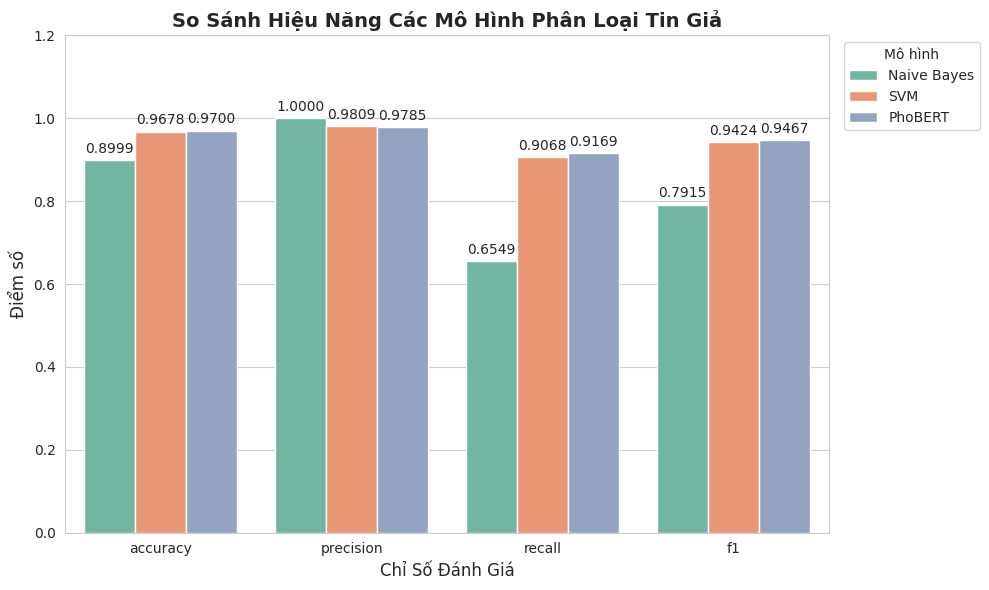


✅ Đã lưu biểu đồ so sánh (thang đo 0-1): model_comparison_chart_decimal.png


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

os.chdir('/content')

print("\n--- BẮT ĐẦU BƯỚC 10: SO SÁNH HIỆU NĂNG ---")

try:
    df_baseline = pd.read_csv("baseline_results.csv")
    df_phobert = pd.read_csv("phobert_results.csv")


    df_compare = pd.concat([df_baseline, df_phobert], ignore_index=True)


    metrics_cols = ["accuracy", "precision", "recall", "f1"]
    for col in metrics_cols:
        if col in df_compare.columns:
            df_compare[col] = df_compare[col] / 100.0

    print("\nBẢNG TỔNG HỢP SO SÁNH HIỆU NĂNG (Scale 0 - 1):")
    print(df_compare.round(4).to_string(index=False))

    df_melt = df_compare.melt(id_vars="model", var_name="Metric", value_name="Score")

    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")

    ax = sns.barplot(data=df_melt, x="Metric", y="Score", hue="model", palette="Set2")


    for container in ax.containers:
        ax.bar_label(container, fmt='%.4f', padding=3)

    plt.title("So Sánh Hiệu Năng Các Mô Hình Phân Loại Tin Giả", fontsize=14, fontweight='bold')

    plt.ylim(0, 1.2)
    plt.ylabel("Điểm số", fontsize=12)
    plt.xlabel("Chỉ Số Đánh Giá", fontsize=12)

    plt.legend(title="Mô hình", bbox_to_anchor=(1.01, 1), loc='upper left')

    plt.tight_layout()
    plt.savefig("model_comparison_chart_decimal.png", dpi=300)
    plt.show()

    print("\n✅ Đã lưu biểu đồ so sánh (thang đo 0-1): model_comparison_chart_decimal.png")

except FileNotFoundError:
    print("Lỗi: Vẫn không tìm thấy file. Hãy kiểm tra lại cột bên trái xem file có bị đổi tên không nhé.")
